# YAMNet 줄 끊김 감지 — `plz` 데이터셋 재학습

## 목표
`dataset/plz/*.m4a` (작은 볼륨으로 녹음된 줄 끊김 소리 24개)를
**증폭 → WAV 저장 → 재넘버링 → YAMNet 임베딩 학습**으로 1-class 이상감지 모델을 만든다.

## 단계
1. **증폭 함수** — peak normalize + 추가 게인 + 클리핑 보호
2. **m4a → 증폭 → WAV** 로 저장 (`dataset/plz_wav/`)
3. **`rope_break_001.wav ~` 재넘버링**
4. **1-class 학습** — YAMNet 임베딩 → robust centroid → LOFO CV → 임계값 자동 선택
5. **테스트 코드** — 파일 / 폴더 단위 감지

## 산출물 (기존 inference 코드와 호환)
- `anomaly_centroid.npy` — 1024-d centroid
- `anomaly_embeddings.npy` — 학습에 쓰인 모든 프레임 임베딩 (참조용)
- `anomaly_config.json` — threshold, frame_sec, hop_sec, min_frame_rms 등

## Step 1. 라이브러리 & YAMNet 로드

In [84]:
import os
import glob
import json
import warnings

warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

import numpy as np
import librosa
import soundfile as sf
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from pydub import AudioSegment
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)

print(f'TensorFlow: {tf.__version__}')
yamnet = hub.load('https://tfhub.dev/google/yamnet/1')
print('YAMNet 로드 완료')

TensorFlow: 2.20.0
YAMNet 로드 완료


## Step 2. 설정값

In [85]:
# 경로
SRC_DIR = 'dataset/plz'            # 원본 m4a (입력)
WAV_DIR = 'dataset/plz_wav'        # 증폭된 wav (출력 = 학습 데이터)
WAV_PREFIX = 'rope_break'

# 오디오 파라미터
SR = 16000                         # YAMNet 요구 샘플레이트

# 증폭 설정
PEAK_TARGET = 0.95                 # peak normalize 목표치 ( [-1, 1] )
EXTRA_GAIN_DB = 0.0                # 추가 게인 (dB). 여전히 너무 작으면 6~12 정도로 키워서 재실행

# YAMNet 프레임
FRAME_SEC = 0.96
HOP_SEC = 0.48
MIN_FRAME_RMS = 0.01

# 데이터 증강 (peak normalize 이후에도 의미가 보존되는 것만)
AUG_PER_FILE = 3
NOISE_SNR_DB = (25, 40)
TIME_SHIFT_MAX = 0.10

# 학습/평가
OUTLIER_QUANTILE = 0.10
TARGET_RECALL = 0.95
THRESHOLD_MARGIN = 0.02

# 저장 경로
CENTROID_PATH = 'anomaly_centroid.npy'
EMBEDDINGS_PATH = 'anomaly_embeddings.npy'
CONFIG_PATH = 'anomaly_config.json'

os.makedirs(WAV_DIR, exist_ok=True)

print(f'src  : {SRC_DIR}')
print(f'wav  : {WAV_DIR}')
print(f'peak target: {PEAK_TARGET}  extra gain: {EXTRA_GAIN_DB} dB')
print(f'frame {FRAME_SEC}s / hop {HOP_SEC}s')

src  : dataset/plz
wav  : dataset/plz_wav
peak target: 0.95  extra gain: 0.0 dB
frame 0.96s / hop 0.48s


## Step 3. 증폭 함수

1. `peak_normalize` : 가장 큰 진폭을 `PEAK_TARGET` (기본 0.95) 으로 맞춘다. 볼륨이 작을수록 크게 증폭된다.
2. `EXTRA_GAIN_DB` : 이후 추가로 게인을 더 준다 (필요 시).
3. **하드 클리핑**으로 `[-1, 1]` 범위 보장 (WAV 저장 시 오버플로 방지).

정적이 섞인 조용한 파일에서 peak는 뾰족한 노이즈 1~2개가 좌우한다. 전체가 여전히 작게 느껴지면 `EXTRA_GAIN_DB`를 6~12 로 올려 다시 실행한다.

In [86]:
def amplify(wav, peak_target=PEAK_TARGET, extra_gain_db=EXTRA_GAIN_DB):
    wav = wav.astype(np.float32)
    peak = float(np.max(np.abs(wav)))
    if peak < 1e-6:
        return wav
    # 1) peak normalize
    gain = peak_target / peak
    # 2) extra gain
    gain *= float(10 ** (extra_gain_db / 20))
    wav = wav * gain
    # 3) hard clip
    return np.clip(wav, -1.0, 1.0).astype(np.float32)


def describe_volume(wav, label=''):
    peak = float(np.max(np.abs(wav)))
    rms = float(np.sqrt(np.mean(wav ** 2)))
    peak_db = 20 * np.log10(peak + 1e-12)
    rms_db = 20 * np.log10(rms + 1e-12)
    print(f'  {label:>12s}  peak {peak:.4f} ({peak_db:+6.2f} dBFS)  rms {rms:.4f} ({rms_db:+6.2f} dBFS)')


# Sanity check on one file
sample_src = sorted(glob.glob(os.path.join(SRC_DIR, '*.m4a')) +
                    glob.glob(os.path.join(SRC_DIR, '*.mp3')) +
                    glob.glob(os.path.join(SRC_DIR, '*.wav')))
if sample_src:
    audio = AudioSegment.from_file(sample_src[0]).set_frame_rate(SR).set_channels(1)
    raw = np.array(audio.get_array_of_samples(), dtype=np.float32) / float(2 ** (audio.sample_width * 8 - 1))
    amp = amplify(raw)
    print(f'sample: {os.path.basename(sample_src[0])}')
    describe_volume(raw, 'before')
    describe_volume(amp, 'after')
else:
    print(f'[WARN] {SRC_DIR} 에 소스 파일 없음')

sample: 포항공과대학교 102.m4a
        before  peak 0.2990 (-10.49 dBFS)  rms 0.0060 (-44.51 dBFS)
         after  peak 0.9500 ( -0.45 dBFS)  rms 0.0189 (-34.47 dBFS)


## Step 4. m4a → 증폭 → WAV + 재넘버링

`plz/` 안의 모든 오디오(m4a/mp3/wav…)를 16 kHz mono 로 맞추고, 증폭한 뒤
`plz_wav/rope_break_###.wav` 형식으로 저장한다. 기존 `plz_wav/` 내부의 파일은
깨끗하게 비우고 다시 쓴다 (원본 `plz/` 는 건드리지 않음).

In [87]:
SRC_EXTS = ['*.m4a', '*.mp3', '*.wav', '*.ogg', '*.flac', '*.aac', '*.wma']

# 1) 기존 출력 디렉터리의 wav 삭제 (깨끗한 실행)
removed = 0
for f in glob.glob(os.path.join(WAV_DIR, '*.wav')):
    os.remove(f)
    removed += 1
if removed:
    print(f'[cleanup] 기존 wav {removed}개 삭제')

# 2) 소스 수집 (이름순)
src_paths = []
for ext in SRC_EXTS:
    src_paths.extend(glob.glob(os.path.join(SRC_DIR, ext)))
src_paths = sorted(src_paths)
print(f'소스 파일 {len(src_paths)}개\n')

# 3) 변환 + 증폭 + 저장
for i, src in enumerate(src_paths, 1):
    audio = AudioSegment.from_file(src).set_frame_rate(SR).set_channels(1)
    raw = np.array(audio.get_array_of_samples(), dtype=np.float32) /           float(2 ** (audio.sample_width * 8 - 1))
    amp = amplify(raw)

    dst = os.path.join(WAV_DIR, f'{WAV_PREFIX}_{i:03d}.wav')
    sf.write(dst, amp, SR, subtype='PCM_16')

    before_peak = float(np.max(np.abs(raw)))
    after_peak = float(np.max(np.abs(amp)))
    print(f'  [{i:03d}/{len(src_paths):03d}] {os.path.basename(src):40s} '
          f'peak {before_peak:.3f} -> {after_peak:.3f}  '
          f'len {len(raw)/SR:.2f}s')

wav_files = sorted(glob.glob(os.path.join(WAV_DIR, f'{WAV_PREFIX}_*.wav')))
print(f'\n저장 완료: {len(wav_files)}개 -> {WAV_DIR}')

소스 파일 24개

  [001/024] 포항공과대학교 102.m4a                peak 0.299 -> 0.950  len 4.85s
  [002/024] 포항공과대학교 103.m4a                peak 0.145 -> 0.950  len 1.79s
  [003/024] 포항공과대학교 104.m4a                peak 0.156 -> 0.950  len 3.18s
  [004/024] 포항공과대학교 105.m4a                peak 0.097 -> 0.950  len 6.24s
  [005/024] 포항공과대학교 106.m4a                peak 0.145 -> 0.950  len 4.02s
  [006/024] 포항공과대학교 107.m4a                peak 0.094 -> 0.950  len 1.79s
  [007/024] 포항공과대학교 108.m4a                peak 0.640 -> 0.950  len 2.58s
  [008/024] 포항공과대학교 109.m4a                peak 1.000 -> 0.950  len 4.20s
  [009/024] 포항공과대학교 110.m4a                peak 0.143 -> 0.950  len 1.47s
  [010/024] 포항공과대학교 111.m4a                peak 0.251 -> 0.950  len 3.37s
  [011/024] 포항공과대학교 113.m4a                peak 0.080 -> 0.950  len 3.52s
  [012/024] 포항공과대학교 114.m4a                peak 0.119 -

## Step 5. 프레임 분할 + 증강 함수

In [88]:
def peak_normalize(wav, target=PEAK_TARGET):
    peak = float(np.max(np.abs(wav)))
    return wav if peak < 1e-6 else wav * (target / peak)


def split_to_frames(wav, sr=SR, frame_sec=FRAME_SEC, hop_sec=HOP_SEC, min_rms=MIN_FRAME_RMS):
    frame_len = int(frame_sec * sr)
    hop = int(hop_sec * sr)
    if len(wav) < frame_len:
        wav = np.pad(wav, (0, frame_len - len(wav)))
    frames = []
    for start in range(0, len(wav) - frame_len + 1, hop):
        chunk = wav[start:start + frame_len]
        if np.sqrt(np.mean(chunk ** 2)) >= min_rms:
            frames.append(chunk)
    if not frames:
        frames.append(wav[:frame_len])
    return frames


def add_gaussian_noise(wav, snr_db_range, rng):
    snr_db = rng.uniform(*snr_db_range)
    sig_pow = float(np.mean(wav ** 2)) + 1e-12
    noise_pow = sig_pow / (10 ** (snr_db / 10))
    noise = rng.normal(0.0, float(np.sqrt(noise_pow)), size=len(wav)).astype(np.float32)
    return wav + noise


def random_time_shift(wav, max_frac, rng):
    shift = int(len(wav) * rng.uniform(-max_frac, max_frac))
    return np.roll(wav, shift)


def augment(wav, seed):
    rng = np.random.default_rng(seed)
    wav = add_gaussian_noise(wav, NOISE_SNR_DB, rng)
    wav = random_time_shift(wav, TIME_SHIFT_MAX, rng)
    return wav.astype(np.float32)


def extract_embedding(frame):
    _, embeddings, _ = yamnet(frame.astype(np.float32))
    return embeddings.numpy()[0]


print('함수 정의 완료 — peak_normalize / split_to_frames / augment / extract_embedding')

함수 정의 완료 — peak_normalize / split_to_frames / augment / extract_embedding


## Step 6. YAMNet 임베딩 추출 (원본 + 증강)

증폭된 wav 파일에서 원본 프레임과 증강 프레임의 임베딩을 모두 추출해 학습에 사용한다.

In [89]:
files = sorted([f for f in os.listdir(WAV_DIR) if f.endswith('.wav')])
print(f'학습 파일 {len(files)}개 (원본 + 증강 x{AUG_PER_FILE})\n')

all_embeddings = []
all_sources = []
all_is_aug = []

for i, fname in enumerate(files):
    wav_raw, _ = librosa.load(os.path.join(WAV_DIR, fname), sr=SR, mono=True)
    wav_raw = wav_raw.astype(np.float32)

    # 원본 프레임
    wav = peak_normalize(wav_raw)
    for frame in split_to_frames(wav):
        all_embeddings.append(extract_embedding(frame))
        all_sources.append(fname)
        all_is_aug.append(False)

    # 증강 프레임
    for k in range(AUG_PER_FILE):
        wav_aug = peak_normalize(augment(wav_raw, seed=1000 * (i + 1) + k))
        for frame in split_to_frames(wav_aug):
            all_embeddings.append(extract_embedding(frame))
            all_sources.append(fname)
            all_is_aug.append(True)

    if (i + 1) % 5 == 0 or (i + 1) == len(files):
        print(f'  {i+1}/{len(files)} — 누적 프레임 {len(all_embeddings)}')

all_embeddings = np.asarray(all_embeddings, dtype=np.float32)
all_sources = np.asarray(all_sources)
all_is_aug = np.asarray(all_is_aug)

n_orig = int((~all_is_aug).sum())
n_aug = int(all_is_aug.sum())
print(f'\n총 프레임 {all_embeddings.shape[0]} (원본 {n_orig} / 증강 {n_aug})')
print(f'임베딩 차원 {all_embeddings.shape[1]}')

학습 파일 24개 (원본 + 증강 x3)

  5/24 — 누적 프레임 124
  10/24 — 누적 프레임 176
  15/24 — 누적 프레임 352
  20/24 — 누적 프레임 544
  24/24 — 누적 프레임 636

총 프레임 636 (원본 159 / 증강 477)
임베딩 차원 1024


## Step 7. Robust centroid

전체 평균 centroid 를 한 번 계산 → 각 프레임의 유사도 계산 →
하위 `OUTLIER_QUANTILE` (10%) 제외 → 재평균. 불필요한 noise frame 의 영향을 줄인다.

In [90]:
def robust_centroid(embeddings, quantile=OUTLIER_QUANTILE):
    c_tmp = np.mean(embeddings, axis=0)
    sims = cosine_similarity(embeddings, c_tmp.reshape(1, -1)).flatten()
    cutoff = float(np.quantile(sims, quantile))
    keep = sims >= cutoff
    return np.mean(embeddings[keep], axis=0), keep, cutoff


centroid, keep_mask, cutoff = robust_centroid(all_embeddings)
print(f'전체 {len(all_embeddings)} 프레임 -> 유효 {int(keep_mask.sum())}개 사용')
print(f'제외 컷오프 유사도: {cutoff:.4f} (하위 {OUTLIER_QUANTILE*100:.0f}%)')
print(f'centroid shape: {centroid.shape}')

전체 636 프레임 -> 유효 572개 사용
제외 컷오프 유사도: 0.6547 (하위 10%)
centroid shape: (1024,)


## Step 8. Leave-One-File-Out 검증

파일 하나씩 빼고 나머지로 centroid 재학습 -> 빠진 파일의 max 유사도 기록.
테스트 파일의 **원본 프레임만** 사용한다 (증강은 오염 방지 위해 제외).

In [91]:
def file_max_sim(fname, c, orig_only=True):
    m = (all_sources == fname)
    if orig_only:
        m &= (~all_is_aug)
    sims = cosine_similarity(all_embeddings[m], c.reshape(1, -1)).flatten()
    return float(sims.max())


lofo_sims = np.zeros(len(files), dtype=np.float32)
for i, test_file in enumerate(files):
    train_mask = all_sources != test_file
    c_fold, _, _ = robust_centroid(all_embeddings[train_mask])
    lofo_sims[i] = file_max_sim(test_file, c_fold, orig_only=True)

print(f'LOFO max 유사도 — 평균 {lofo_sims.mean():.4f} | 최소 {lofo_sims.min():.4f} | 최대 {lofo_sims.max():.4f}')
print()
print(f'{"th":>6} | {"recall":>6} | detected')
for t in np.arange(0.50, 0.96, 0.05):
    detected = int((lofo_sims >= t).sum())
    print(f'{t:>6.2f} | {detected/len(lofo_sims):>6.3f} | {detected}/{len(lofo_sims)}')

LOFO max 유사도 — 평균 0.8947 | 최소 0.7349 | 최대 0.9566

    th | recall | detected
  0.50 |  1.000 | 24/24
  0.55 |  1.000 | 24/24
  0.60 |  1.000 | 24/24
  0.65 |  1.000 | 24/24
  0.70 |  1.000 | 24/24
  0.75 |  0.958 | 23/24
  0.80 |  0.917 | 22/24
  0.85 |  0.875 | 21/24
  0.90 |  0.500 | 12/24
  0.95 |  0.125 | 3/24


## Step 9. 임계값 자동 선택

LOFO 결과에서 `TARGET_RECALL` (기본 0.95) 이상을 만족하는 가장 엄격한 임계값을 뽑고,
`THRESHOLD_MARGIN` 만큼 낮춰 노이즈 여유를 둔다.

In [96]:
# 임계값 고정 (0.68)
threshold = 0.68

# 참고: LOFO recall 기반 자동 후보 임계값 (비교용)
sorted_sims = np.sort(lofo_sims)
min_detected = max(1, min(int(np.ceil(TARGET_RECALL * len(sorted_sims))), len(sorted_sims)))
threshold_raw = float(sorted_sims[len(sorted_sims) - min_detected])

recall_at_th = float((lofo_sims >= threshold).mean())
detected_at_th = int((lofo_sims >= threshold).sum())

print(f'고정 임계값: {threshold:.4f}')
print(f'(참고) recall>={TARGET_RECALL:.2f} 기준 자동 후보 임계값: {threshold_raw:.4f}')
print(f'-> LOFO recall {recall_at_th:.3f}  ({detected_at_th}/{len(lofo_sims)} 감지)')

고정 임계값: 0.6800
(참고) recall>=0.95 기준 자동 후보 임계값: 0.7948
-> LOFO recall 1.000  (24/24 감지)


## Step 10. 시각화

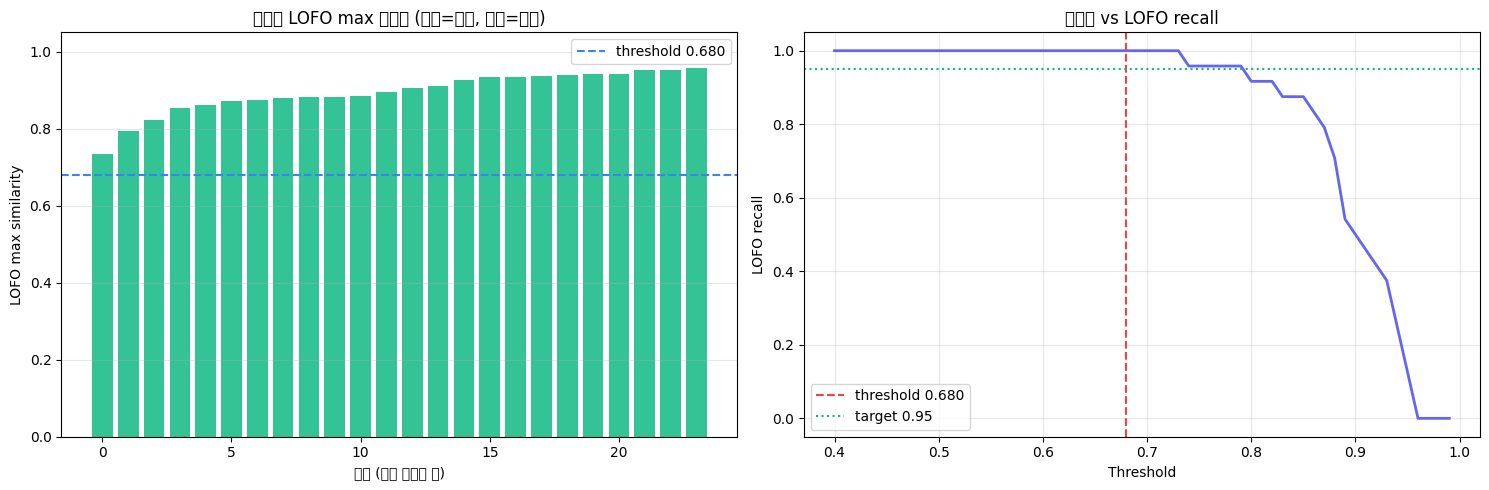


모든 파일 감지됨.


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = np.argsort(lofo_sims)
colors = ['#10b981' if lofo_sims[i] >= threshold else '#ef4444' for i in order]
axes[0].bar(range(len(order)), lofo_sims[order], color=colors, alpha=0.85)
axes[0].axhline(y=threshold, color='#3b82f6', linestyle='--', label=f'threshold {threshold:.3f}')
axes[0].set_xlabel('파일 (낮은 유사도 순)')
axes[0].set_ylabel('LOFO max similarity')
axes[0].set_title('파일별 LOFO max 유사도 (녹색=감지, 빨강=놓침)')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

ts = np.linspace(0.40, 0.99, 60)
recalls = [float((lofo_sims >= t).mean()) for t in ts]
axes[1].plot(ts, recalls, color='#6366f1', linewidth=2)
axes[1].axvline(x=threshold, color='#ef4444', linestyle='--', label=f'threshold {threshold:.3f}')
axes[1].axhline(y=TARGET_RECALL, color='#10b981', linestyle=':', label=f'target {TARGET_RECALL}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('LOFO recall')
axes[1].set_title('임계값 vs LOFO recall')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

missed = [(files[i], float(lofo_sims[i])) for i in range(len(files)) if lofo_sims[i] < threshold]
if missed:
    print(f'\n놓친 파일 {len(missed)}개 (< {threshold:.3f}):')
    for fn, v in sorted(missed, key=lambda x: x[1]):
        print(f'  {fn}: {v:.3f}')
else:
    print('\n모든 파일 감지됨.')

## Step 11. 모델 저장

`input/audio/realtime_detect.py` 와 `input/audio/test_with_wav.py` 가 그대로 사용하는
`anomaly_centroid.npy` / `anomaly_config.json` 스키마 유지.

In [98]:
np.save(CENTROID_PATH, centroid)
np.save(EMBEDDINGS_PATH, all_embeddings)

config = {
    'threshold': float(threshold),
    'threshold_raw': float(threshold_raw),
    'threshold_margin': float(THRESHOLD_MARGIN),
    'num_files': int(len(files)),
    'num_frames': int(all_embeddings.shape[0]),
    'num_original_frames': int(n_orig),
    'num_aug_frames': int(n_aug),
    'aug_per_file': int(AUG_PER_FILE),
    'noise_snr_db': list(NOISE_SNR_DB),
    'time_shift_max': float(TIME_SHIFT_MAX),
    'outlier_quantile': float(OUTLIER_QUANTILE),
    'source': f'{WAV_DIR}_framewise_augmented',
    'peak_target': float(PEAK_TARGET),
    'extra_gain_db': float(EXTRA_GAIN_DB),
    'frame_sec': float(FRAME_SEC),
    'hop_sec': float(HOP_SEC),
    'min_frame_rms': float(MIN_FRAME_RMS),
    'peak_normalize': True,
    'inference_mode': 'max_pooling',
    'cv_method': 'LOFO',
    'cv_test_recall': float(recall_at_th),
    'target_recall': float(TARGET_RECALL),
    'embedding_dim': int(centroid.shape[0]),
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print('저장 완료:')
print(f'  {CENTROID_PATH}')
print(f'  {EMBEDDINGS_PATH}')
print(f'  {CONFIG_PATH}')
print()
print(json.dumps(config, indent=2, ensure_ascii=False))

저장 완료:
  anomaly_centroid.npy
  anomaly_embeddings.npy
  anomaly_config.json

{
  "threshold": 0.68,
  "threshold_raw": 0.794765830039978,
  "threshold_margin": 0.02,
  "num_files": 24,
  "num_frames": 636,
  "num_original_frames": 159,
  "num_aug_frames": 477,
  "aug_per_file": 3,
  "noise_snr_db": [
    25,
    40
  ],
  "time_shift_max": 0.1,
  "outlier_quantile": 0.1,
  "source": "dataset/plz_wav_framewise_augmented",
  "peak_target": 0.95,
  "extra_gain_db": 0.0,
  "frame_sec": 0.96,
  "hop_sec": 0.48,
  "min_frame_rms": 0.01,
  "peak_normalize": true,
  "inference_mode": "max_pooling",
  "cv_method": "LOFO",
  "cv_test_recall": 1.0,
  "target_recall": 0.95,
  "embedding_dim": 1024
}


## Step 12. 테스트 코드

저장된 모델을 로드하여 임의 wav 파일 또는 폴더에 대해 감지를 수행한다.
학습 때와 동일한 전처리(peak normalize + frame 분할 + max pooling)를 적용해
학습/실시간/파일 테스트 결과가 일관되도록 했다.

In [99]:
loaded_centroid = np.load(CENTROID_PATH)
with open(CONFIG_PATH) as f:
    loaded_config = json.load(f)

TH = loaded_config['threshold']
print(f'로드: centroid {loaded_centroid.shape}  threshold {TH:.4f}\n')


def predict_wav(path):
    """단일 wav 파일에 대한 max 유사도 + 프레임별 유사도."""
    wav, _ = librosa.load(path, sr=SR, mono=True)
    wav = peak_normalize(wav.astype(np.float32))
    frames = split_to_frames(wav)
    sims = []
    for frame in frames:
        emb = extract_embedding(frame)
        s = float(cosine_similarity(emb.reshape(1, -1), loaded_centroid.reshape(1, -1))[0][0])
        sims.append(s)
    return (max(sims) if sims else 0.0), sims, len(frames)


def render_bar(value, width=30):
    v = max(0.0, min(1.0, float(value)))
    filled = int(v * width)
    return '#' * filled + '-' * (width - filled)


def test_path(target):
    if os.path.isdir(target):
        paths = sorted(glob.glob(os.path.join(target, '*.wav')))
    elif os.path.isfile(target):
        paths = [target]
    else:
        print(f'[ERR] 경로 없음: {target}')
        return

    if not paths:
        print(f'[ERR] wav 파일이 없습니다: {target}')
        return

    print(f'테스트 대상 {len(paths)}개 / threshold {TH:.4f}')
    print('-' * 80)
    detected = 0
    sims_all = []
    for p in paths:
        mx, _, n = predict_wav(p)
        hit = mx >= TH
        detected += int(hit)
        sims_all.append(mx)
        mark = '★ BREAK   ' if hit else '  normal  '
        print(f'  [{render_bar(mx)}] max {mx:.3f}  frames={n:>2}  {mark} {os.path.basename(p)}')
    print('-' * 80)
    print(f'  감지 {detected}/{len(paths)} ({detected/len(paths)*100:.1f}%) | '
          f'max sim avg {np.mean(sims_all):.4f} / min {np.min(sims_all):.4f} / max {np.max(sims_all):.4f}')


# 1) 학습에 쓴 파일들 중 앞 몇 개 감지 확인
test_path(WAV_DIR)

로드: centroid (1024,)  threshold 0.6800

테스트 대상 24개 / threshold 0.6800
--------------------------------------------------------------------------------
  [###########################---] max 0.901  frames= 8  ★ BREAK    rope_break_001.wav
  [########################------] max 0.802  frames= 2  ★ BREAK    rope_break_002.wav
  [##########################----] max 0.886  frames= 5  ★ BREAK    rope_break_003.wav
  [##########################----] max 0.898  frames=10  ★ BREAK    rope_break_004.wav
  [##########################----] max 0.885  frames= 6  ★ BREAK    rope_break_005.wav
  [###########################---] max 0.908  frames= 2  ★ BREAK    rope_break_006.wav
  [#########################-----] max 0.865  frames= 2  ★ BREAK    rope_break_007.wav
  [######################--------] max 0.741  frames= 2  ★ BREAK    rope_break_008.wav
  [##########################----] max 0.876  frames= 2  ★ BREAK    rope_break_009.wav
  [###########################---] max 0.915  frames= 5  ★ BREAK  

### 임의 파일 / 폴더 테스트

아래 셀의 경로를 원하는 값으로 바꿔서 실행하면 된다.

In [ ]:
# 예시 1) 단일 파일
# test_path('dataset/plz_wav/rope_break_001.wav')

# 예시 2) 임의 폴더 내 모든 wav
# test_path('dataset/plz_wav')

# 예시 3) 다른 샘플 비교 (학습에 쓰지 않은 소리로 오탐 확인)
# test_path('dataset/release')
# test_path('dataset/stress')

print('위 셀의 주석을 해제해 원하는 경로로 테스트하세요.')

---
## CLI 테스트

```bash
# WAV 파일 테스트
python input/audio/test_with_wav.py model/yamnet/dataset/plz_wav

# 실시간 마이크 감지
python input/audio/realtime_detect.py
```